Modelo de Clasificación - Predicción de envíos en E- COMMERCE

IMPORTACIÓN COMO PRIMERA INSTANCIA


In [52]:
#Comenzamos importanto las librerías que usaremos

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [53]:
!pip install scikit-learn



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [54]:
#Importamos tres clasificadores de scikit-learn

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier

#Métricas de evaluación 

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

CARGA DE DATOS Y EXPLORACIÓN 





In [55]:
#Carga de datos

df = pd.read_csv(r'c:\Users\lolit\Downloads\Train.csv')

In [56]:
df

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10994,10995,A,Ship,4,1,252,5,medium,F,1,1538,1
10995,10996,B,Ship,4,1,232,5,medium,F,6,1247,0
10996,10997,C,Ship,5,4,242,5,low,F,4,1155,0
10997,10998,F,Ship,5,2,223,6,medium,M,2,1210,0


In [57]:
#Exploración de datos inicial

df.head(11)

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1
5,6,F,Flight,3,1,162,3,medium,F,12,1417,1
6,7,D,Flight,3,4,250,3,low,F,3,2371,1
7,8,F,Flight,4,1,233,2,low,F,48,2804,1
8,9,A,Flight,3,4,150,3,low,F,11,1861,1
9,10,B,Flight,3,2,164,3,medium,F,29,1187,1


In [58]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   ID                   10999 non-null  int64
 1   Warehouse_block      10999 non-null  str  
 2   Mode_of_Shipment     10999 non-null  str  
 3   Customer_care_calls  10999 non-null  int64
 4   Customer_rating      10999 non-null  int64
 5   Cost_of_the_Product  10999 non-null  int64
 6   Prior_purchases      10999 non-null  int64
 7   Product_importance   10999 non-null  str  
 8   Gender               10999 non-null  str  
 9   Discount_offered     10999 non-null  int64
 10  Weight_in_gms        10999 non-null  int64
 11  Reached.on.Time_Y.N  10999 non-null  int64
dtypes: int64(8), str(4)
memory usage: 1.0 MB


In [59]:
df.isnull().sum()

ID                     0
Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_Product    0
Prior_purchases        0
Product_importance     0
Gender                 0
Discount_offered       0
Weight_in_gms          0
Reached.on.Time_Y.N    0
dtype: int64

PREPROCESAMIENTO DE DATOS

-Convertiremos los valores categóricos a valores numéricos.

In [60]:
#Transformación de variables



importancia_map = {'low': 1, 'medium': 2, 'high': 3}
df['Product_importance'] = df['Product_importance'].map(importancia_map)

In [61]:
df = pd.get_dummies(df, columns=['Mode_of_Shipment', 'Warehouse_block', 'Gender'], dtype=int)  

In [62]:
target_col = 'Reached.on.Time_Y.N'
X = df.drop(columns=[target_col])
y = df[target_col]

In [63]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   ID                       10999 non-null  int64
 1   Customer_care_calls      10999 non-null  int64
 2   Customer_rating          10999 non-null  int64
 3   Cost_of_the_Product      10999 non-null  int64
 4   Prior_purchases          10999 non-null  int64
 5   Product_importance       10999 non-null  int64
 6   Discount_offered         10999 non-null  int64
 7   Weight_in_gms            10999 non-null  int64
 8   Reached.on.Time_Y.N      10999 non-null  int64
 9   Mode_of_Shipment_Flight  10999 non-null  int64
 10  Mode_of_Shipment_Road    10999 non-null  int64
 11  Mode_of_Shipment_Ship    10999 non-null  int64
 12  Warehouse_block_A        10999 non-null  int64
 13  Warehouse_block_B        10999 non-null  int64
 14  Warehouse_block_C        10999 non-null  int64
 15  Warehouse_blo

DIVISIÓN DEL DATASET

-Se debe dividir el Dataset para entrenar un conjunto y con el otro realizar pruebas.

In [64]:
from sklearn.model_selection import train_test_split
target_col = 'Reached.on.Time_Y.N'

In [65]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

In [66]:
X = df.drop(columns=[target_col])
y = df[target_col]

In [67]:
print(f"Registros para entrenamiento (X_train): {X_train.shape[0]}")
print(f"Refistros para prueba (X_test): {X_test.shape[0]}")

Registros para entrenamiento (X_train): 8799
Refistros para prueba (X_test): 2200


ENTRENAMIENTO DE MODELOS

En este caso yo elegí los siguientes modelos de aprendizaje supervisado / Clasificación.

1.RandomForestClassifier

2.DecisionTreeClassifier

3.GradientBoostingClassifier

In [70]:
 
model_1 = RandomForestClassifier(random_state=42)
model_1.fit(X_train, y_train)
preds_m1 = model_1.predict(X_test)


model_2 = DecisionTreeClassifier(random_state=42)
model_2.fit(X_train, y_train)
preds_m2 = model_2.predict(X_test)


model_3 = GradientBoostingClassifier(random_state=42)
model_3.fit(X_train, y_train)
preds_m3 = model_3.predict(X_test)




EVALUACIÓN Y COMPARACIÓN DE LOS MODELOS ELEGIDOS

In [71]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

acc_m1 = accuracy_score(y_test, preds_m1)
acc_m2 = accuracy_score(y_test, preds_m2)
acc_m3 = accuracy_score(y_test, preds_m3)

In [72]:
resultados_accuracy = {
    'Random Forest': acc_m1,
    'Arbol de Desición': acc_m2,
    'Gradient Boosting': acc_m3
}

In [75]:
print("===REPORTE DE CLASIFICACIÓN===")
print("\n1.  RANDOM FOREST:")
print(classification_report(y_test, preds_m1))


print("\n2.  ÁRBOL DE DESICIÓN:")
print(classification_report(y_test, preds_m2))


print("\n3.  GRADIENT BOOSTING:")
print(classification_report(y_test, preds_m3))


===REPORTE DE CLASIFICACIÓN===

1.  RANDOM FOREST:
              precision    recall  f1-score   support

           0       0.55      0.76      0.64       887
           1       0.78      0.59      0.67      1313

    accuracy                           0.66      2200
   macro avg       0.67      0.67      0.66      2200
weighted avg       0.69      0.66      0.66      2200


2.  ÁRBOL DE DESICIÓN:
              precision    recall  f1-score   support

           0       0.57      0.54      0.56       887
           1       0.70      0.72      0.71      1313

    accuracy                           0.65      2200
   macro avg       0.63      0.63      0.63      2200
weighted avg       0.65      0.65      0.65      2200


3.  GRADIENT BOOSTING:
              precision    recall  f1-score   support

           0       0.56      0.94      0.70       887
           1       0.92      0.51      0.66      1313

    accuracy                           0.68      2200
   macro avg       0.74      

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns

modelos =  list(resultados_accuracy.keys())
valores_accuracy = list(resultados_accuracy.values())


GRÁFICOS DE BARRAS


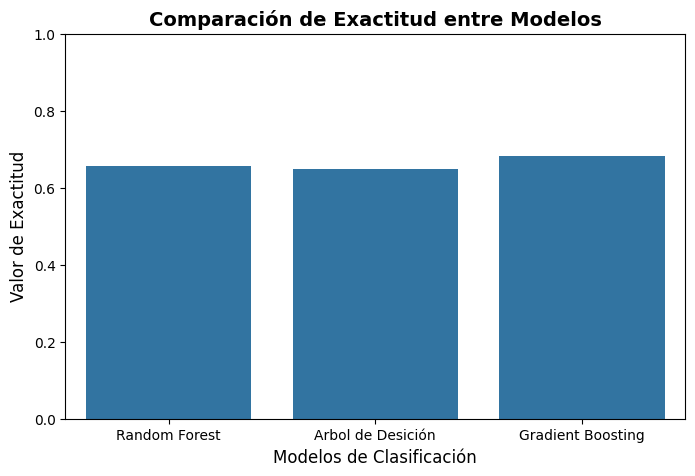

In [85]:
plt.figure(figsize=(8, 5))
sns.barplot(x=modelos, y=valores_accuracy)

plt.title('Comparación de Exactitud entre Modelos', fontsize=14, fontweight='bold')
plt.xlabel('Modelos de Clasificación', fontsize=12)
plt.ylabel('Valor de Exactitud', fontsize=12)
plt.ylim(0, 1.0)

plt.show()


MATRICES DE CONFUSIÓN

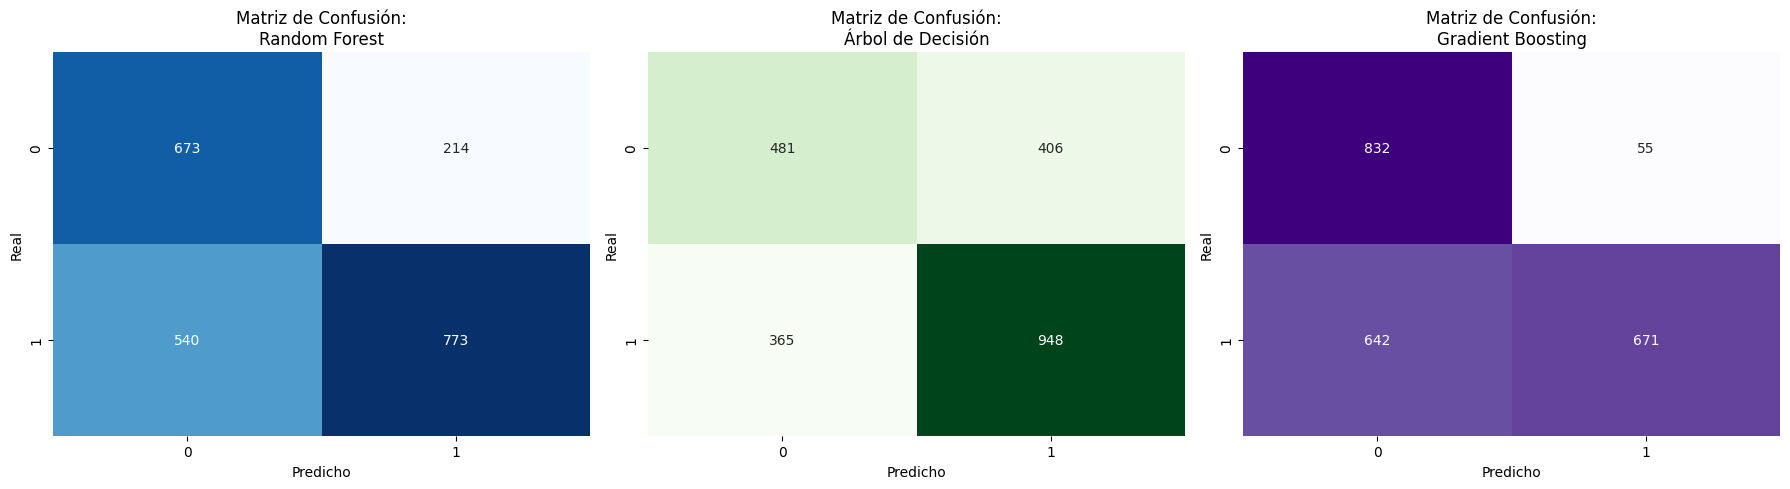

In [91]:
# Calcular las matrices de confusión numéricas
cm_m1 = confusion_matrix(y_test, preds_m1)
cm_m2 = confusion_matrix(y_test, preds_m2)
cm_m3 = confusion_matrix(y_test, preds_m3)

# Crear una figura con 3 subgráficos en una sola fila
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Matriz 1: Random Forest
sns.heatmap(cm_m1, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Matriz de Confusión:\nRandom Forest')
axes[0].set_xlabel('Predicho')
axes[0].set_ylabel('Real')

# Matriz 2: Árbol de Decisión
sns.heatmap(cm_m2, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False)
axes[1].set_title('Matriz de Confusión:\nÁrbol de Decisión')
axes[1].set_xlabel('Predicho')
axes[1].set_ylabel('Real')

# Matriz 3: Gradient Boosting
sns.heatmap(cm_m3, annot=True, fmt='d', cmap='Purples', ax=axes[2], cbar=False)
axes[2].set_title('Matriz de Confusión:\nGradient Boosting')
axes[2].set_xlabel('Predicho')
axes[2].set_ylabel('Real')

plt.tight_layout()
plt.show()




CONCLUSIÓN:

El modelo que más excatitud tuvo según los resultados generados en el código mediante el entrenamiento y el testeo, es el modelo de clasificación GradientBoostingClassifier, el cuál tuvo más presición, tiene un equilibrio de predicción, combina árboles de desición.
En el gráfico de matriz de confusión también podemos notar  la suma entre 832 y 671 = 1.503 para poder saber los aciertos totales.

El modelo menos favorable para este tipo de análisis del Dataset seleccionado, es DecisionTreeClassifier (Árbol de desición), obtuvo menos puntualidad, ya que al parecer suele sobreajustar (overfitting), por ello su rigidez no es lo más recomendable en este caso. Podemos observarlo realizando la suma de acierto en el gráfico de confusión de matrices, la cual es, 481 + 948 = 1.429, aquí podemos ver una notable diferencia.

Esto convierte a Random Forest en un modelo intermedio, demuestra ser más eficiente por que el árbol de desición, pero no lo sufieciente como  grandient  Boosting, lo podemos observar en la gráfica final con más certeza, sumando su puntaje dandonos un resultado de 1.446.